In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import torch
import sys
from scipy import stats
from scipy.stats import norm

# Increase the font scale for seaborn
sns.set(font_scale=1.5)  # Adjust this value to increase or decrease font size
sns.set_style("white")  # Set the background to white

sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor/')
from estimate_bayesian_fdr import *
from differential_splicing import *

In [2]:
# Main path set up
main_path="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/Simulations/2025/manuscript_sim_analysis/0205"

# List the directories in the main path
dirs = os.listdir(main_path)
# Which dirs have "NoCellType_Random" in them 
dirs = [d for d in dirs if "NoCellType_Random" in d]

print(dirs)

['analysis_20250205_111836_PropNeg_0.9_K_2_NoWaypoints_Prior_NoGlobalPrior_NumEpochs_500_LearnedConc_Inits_2_NoCellType_Random_71', 'analysis_20250205_111320_PropNeg_0.5_K_2_NoWaypoints_Prior_GlobalPrior_NumEpochs_500_ConcPrior_inf_Inits_2_NoCellType_Random_48', 'analysis_20250205_111849_PropNeg_0.9_K_2_NoWaypoints_Prior_GlobalPrior_NumEpochs_500_ConcPrior_inf_Inits_2_NoCellType_Random_93', 'analysis_20250205_111320_PropNeg_0.5_K_2_NoWaypoints_Prior_NoGlobalPrior_NumEpochs_500_LearnedConc_Inits_2_NoCellType_Random_81', 'analysis_20250205_111320_PropNeg_0.1_K_2_NoWaypoints_Prior_NoGlobalPrior_NumEpochs_500_LearnedConc_Inits_2_NoCellType_Random_86', 'analysis_20250205_111822_PropNeg_0.1_K_2_NoWaypoints_Prior_GlobalPrior_NumEpochs_500_ConcPrior_inf_Inits_2_NoCellType_Random_62', 'analysis_20250205_111839_PropNeg_0.9_K_2_NoWaypoints_Prior_GlobalPrior_NumEpochs_500_LearnedConc_Inits_2_NoCellType_Random_34', 'analysis_20250205_111810_PropNeg_0.1_K_2_NoWaypoints_Prior_GlobalPrior_NumEpochs_50

In [3]:
# Choose which simulation directory to analyze 
dir_analyze=dirs[1]
print(dir_analyze)

# Set up the path to the simulation directory
sim_dir=os.path.join(main_path,dir_analyze)

# Print the names of the files in the simulation directory
files = os.listdir(sim_dir)
print(files)

analysis_20250205_111320_PropNeg_0.5_K_2_NoWaypoints_Prior_GlobalPrior_NumEpochs_500_ConcPrior_inf_Inits_2_NoCellType_Random_48
['clustermap.png', 'ALBF_vs_estimated_difference.png', 'losses.png', 'assignment_correlations.png', 'ALBF_vs_simulated_difference.png', 'est_deltapsi_vs_difference.png', 'pi_barplot.png', 'simulated_vs_estimated_difference.png', 'nmf_clustermap.png', 'nmf_umap.png.pdf', 'ALBF_scores.csv', 'pi_df.csv', 'albf_vs_difference.png', 'random_init_31291_loss_curve.png', 'random_init_40011_loss_curve.png', 'cell_type_psi_df.csv', 'ALBF_violin_plot.png', 'final_results.csv', 'ALBF_scores_with_FDR.csv', 'ALBF_report.txt', 'umap.png.pdf', 'roc_curve.png', 'est_deltapsi_vs_difference.pdf', 'parameters.json', 'precision_recall_curve.png', 'analysis_report.txt', 'precision_recall_curve.pdf', 'ALBF_score_distribution.png']


In [4]:
sim_dir

'/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/Simulations/2025/manuscript_sim_analysis/0205/analysis_20250205_111320_PropNeg_0.5_K_2_NoWaypoints_Prior_GlobalPrior_NumEpochs_500_ConcPrior_inf_Inits_2_NoCellType_Random_48'

In [5]:
# Extract PropNeg_0.5 from sim_dir 
prop_neg = sim_dir.split("_")[-15]
print(prop_neg)

0.5


In [6]:
# Original PSI_df from simulation
PSI_df = pd.read_csv(os.path.join(sim_dir, "cell_type_psi_df.csv"))

# Load learned pis vector 
pis = pd.read_csv(os.path.join(sim_dir, "pi_df.csv"))
pis = pis.sort_values(by=['Factor'])
pis = pis["pi"].values

In [7]:
# let's load the final_results.csv file 
albf_scores = pd.read_csv(os.path.join(sim_dir, "ALBF_scores.csv"))
# rename the first two columns to be sim_psi_1 and sim_psi_2
albf_scores = albf_scores.rename(columns={"0": "latent_psi_1", "1": "latent_psi_2"})

print("Number of ALBF values greater than 1: ", len(albf_scores[albf_scores["ALBF"] > 1]))
print("Number of ALBF values less than 1: ", len(albf_scores[albf_scores["ALBF"] < 1]))
print("Number of ALBF values less than 0: ", len(albf_scores[albf_scores["ALBF"] < 0]))

em = EMDifferentialSplicing(albf_scores["ALBF"], initial_p=0.5, max_iter=200)
results = em.fit()
albf_scores["posterior_probs"] = results["posterior_probs"]

# lets get percentile ALBF values of negative labels for calibration analysis of positive labels
threshold = [0.8, 0.9, 0.95, 0.975, 0.99]

for thres in threshold:
    # make a new column for each percentile in albf_scores 
    albf_scores[f"FDR_thres_{thres}"] = False
    # check ALBF values if tehy are greater than the percentile value label them as sig 
    albf_scores[f"FDR_thres_{thres}"] = albf_scores["posterior_probs"] >= thres

    # calculate the number of significant values, get FDR 
    tp = albf_scores[(albf_scores["true_label"] == "positive") & (albf_scores[f"FDR_thres_{thres}"])].shape[0]
    fp = albf_scores[(albf_scores["true_label"] == "negative") & (albf_scores[f"FDR_thres_{thres}"])].shape[0]
    tn = albf_scores[(albf_scores["true_label"] == "negative") & (~albf_scores[f"FDR_thres_{thres}"])].shape[0]
    fn = albf_scores[(albf_scores["true_label"] == "positive") & (~albf_scores[f"FDR_thres_{thres}"])].shape[0]
    
    print(f"At {thres} threshold on FDR, the expected FDR is {1-(thres):.2f}")
    print(f"At {thres} threshold on FDR, number of true positives: {tp}, number of false positives: {fp}")
    print(f"At {thres} threshold on FDR, number of true negatives: {tn}, number of false negatives: {fn}")

    fdr = fp / (fp + tp)
    fnr = fn / (fn + tp)
    print(f"At {thres} threshold on FDR, False Discovery Rate: {fdr:.2f}")
    print(f"At {thres} threshold on FDR, False Negative Rate: {fnr:.2f}")

    print(f"-----------------------------------")
    print(f"-----------------------------------")

# reindex the albf_scores using junction_id_index so row index matches 
albf_scores = albf_scores.reset_index(drop=True)

Number of ALBF values greater than 1:  7402
Number of ALBF values less than 1:  8492
Number of ALBF values less than 0:  4
Initial Statistics:
Original ALBF range: [-0.00, 1396.41]
b_j range: [0.4549, 1.0000]

Iteration 1:
p: 0.707732
log likelihood: -6191.548611
q_s1 range: [0.454904, 1.000000]

Iteration 2:
p: 0.824983
log likelihood: -6320.986166
q_s1 range: [0.668967, 1.000000]

Likelihood decreased, using best parameters
At 0.8 threshold on FDR, the expected FDR is 0.20
At 0.8 threshold on FDR, number of true positives: 7110, number of false positives: 90
At 0.8 threshold on FDR, number of true negatives: 7857, number of false negatives: 837
At 0.8 threshold on FDR, False Discovery Rate: 0.01
At 0.8 threshold on FDR, False Negative Rate: 0.11
-----------------------------------
-----------------------------------
At 0.9 threshold on FDR, the expected FDR is 0.10
At 0.9 threshold on FDR, number of true positives: 6854, number of false positives: 78
At 0.9 threshold on FDR, number o

In [8]:
FDR_ALBF = albf_scores[albf_scores["posterior_probs"] >= 0.95].sort_values(by="ALBF").iloc[0]["ALBF"]
print(f"The ALBF at the 5% FDR threshold is: {FDR_ALBF}")

The ALBF at the 5% FDR threshold is: 3.1304874


The means are: tensor([ 2.1959, -2.7740], dtype=torch.float64)
The variances are: tensor([0.0211, 0.0286], dtype=torch.float64)
The combined mean is: 0.018088502809405327
The combined variance is: 0.024389930069446564
The means are: [2.1959314, -2.773974, 0.018088502809405327]
The variances are: [0.021099009, 0.028609002, 0.024389930069446564]
The mean of the sampled PSI values is: 0.8987739024453981
The mean of the sampled PSI values is: 0.05280326075383686
The mean of the sampled PSI values is: 0.47835259426592397


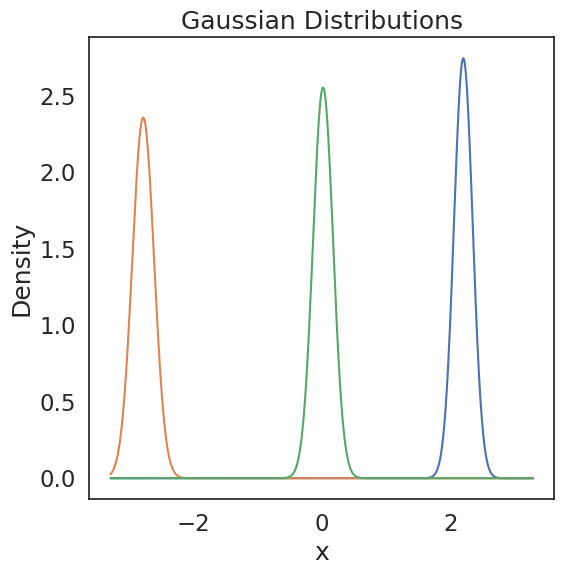

In [9]:
plot_junc_dists(albf_scores, 15796, pis)

(array([6999.,  573.,  210.,  122.,   79.,   45.,   52.,   39.,   44.,
          22.,   31.,   31.,   31.,   29.,   31.,   14.,   24.,   16.,
          22.,   23.,   17.,   14.,   21.,   16.,   25.,   23.,   19.,
          25.,   25.,   22.,   17.,   17.,   25.,   17.,   21.,   22.,
          36.,   29.,   37.,   30.,   44.,   39.,   42.,   47.,   49.,
          67.,   76.,  115.,  194., 6326.]),
 array([0.49999237, 0.50999252, 0.51999268, 0.52999283, 0.53999298,
        0.54999313, 0.55999329, 0.56999344, 0.57999359, 0.58999374,
        0.5999939 , 0.60999405, 0.6199942 , 0.62999435, 0.63999451,
        0.64999466, 0.65999481, 0.66999496, 0.67999512, 0.68999527,
        0.69999542, 0.70999557, 0.71999573, 0.72999588, 0.73999603,
        0.74999619, 0.75999634, 0.76999649, 0.77999664, 0.7899968 ,
        0.79999695, 0.8099971 , 0.81999725, 0.82999741, 0.83999756,
        0.84999771, 0.85999786, 0.86999802, 0.87999817, 0.88999832,
        0.89999847, 0.90999863, 0.91999878, 0.92999893, 

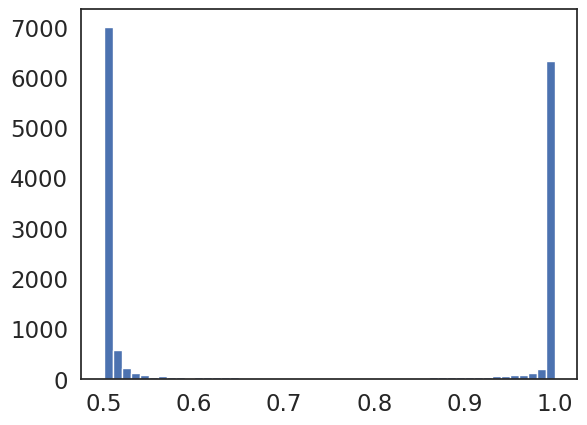

In [10]:
# calculate sigmoid on ALBF 
albf_scores["sigmoid_ALBF"] = 1 / (1 + np.exp(-albf_scores["ALBF"]))
# make histogram of sigmoid ALBF 
plt.hist(albf_scores["sigmoid_ALBF"], bins=50) # clearly bimodal from 0.5-1

In [11]:
# Sort ALBF values so that they are in order aligned with true label 
albf_scores = albf_scores.sort_values(by="ALBF", ascending=True, inplace=False)

,latent_psi_1,latent_psi_2,junction_id_index,ALBF,difference,true_label,Cluster,true_label_binary,delta_est,predicted_label,...,loc_0,mu_1,loc_1,posterior_probs,FDR_thres_0.8,FDR_thres_0.9,FDR_thres_0.95,FDR_thres_0.975,FDR_thres_0.99,sigmoid_ALBF
3895,0.024665,0.024541,3895,-0.000031,0.000000,negative,50272,0,0.000124,0,...,0.025116,-3.683833,0.025015,0.454904,False,False,False,False,False,0.499992
4213,0.783552,0.784500,4213,-0.000019,0.000000,negative,51525,0,0.000949,0,...,0.014400,1.288010,0.014371,0.454906,False,False,False,False,False,0.499995
2343,0.044872,0.047048,2343,-0.000004,0.000000,negative,44551,0,0.002177,0,...,0.073306,-3.070705,0.074043,0.454910,False,False,False,False,False,0.499999
1866,0.387670,0.387517,1866,-0.000001,0.000000,negative,39075,0,0.000153,0,...,0.012733,-0.459277,0.012725,0.454911,False,False,False,False,False,0.500000
7714,0.128597,0.129091,7714,0.000000,0.000000,negative,7504,0,0.000494,0,...,0.010134,-1.914221,0.010026,0.454911,False,False,False,False,False,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14499,0.397198,0.000006,14499,893.655000,0.386005,positive,34687,1,0.397192,1,...,0.003510,-11.959226,0.034611,1.000000,True,True,True,True,True,1.000000
10024,0.278185,0.999982,10024,913.333070,0.679500,positive,12651,1,0.721798,1,...,0.003339,10.952597,0.036370,1.000000,True,True,True,True,True,1.000000
4879,0.000031,0.999921,4879,949.460500,0.953304,positive,56597,1,0.999891,1,...,0.060512,9.455819,0.042736,1.000000,True,True,True,True,True,1.000000
14500,0.188299,0.999966,14500,1224.042400,0.772009,positive,34687,1,0.811667,1,...,0.009549,10.272194,0.018794,1.000000,True,True,True,True,True,1.000000


<Figure size 2000x1000 with 0 Axes>

Text(0.5, 0, 'ALBF')

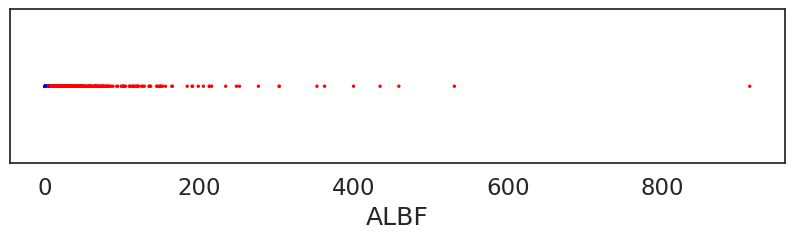

In [12]:
# Now sample 2000 points and put them all on the same horizontal line with x corresponding to ALBF and y corresponding to 0
# random rows sampled
plt.figure(figsize=(10, 2))
num_sample = 1000
rows = np.random.choice(albf_scores.index, num_sample)
# make ylim very small and dont show y axis ticks 
plt.ylim(-0.01, 0.01)
# remove y axis ticks
plt.yticks([])
# plot the ALBF values on the horizontal line
plt.scatter(albf_scores.loc[rows, "ALBF"], np.zeros(num_sample), c=albf_scores.loc[rows, "true_label"].map({"positive": "red", "negative": "blue"}), s=2)
plt.xlabel("ALBF")

In [16]:
albf_scores[["true_label", "difference", "ALBF"]]

,true_label,difference,ALBF
3895,negative,0.000000,-0.000031
4213,negative,0.000000,-0.000019
2343,negative,0.000000,-0.000004
1866,negative,0.000000,-0.000001
7714,negative,0.000000,0.000000
...,...,...,...
14499,positive,0.386005,893.655000
10024,positive,0.679500,913.333070
4879,positive,0.953304,949.460500
14500,positive,0.772009,1224.042400


In [19]:
albf_scores["FDR_thres_0.95"].value_counts()

FDR_thres_0.95
False    9170
True     6724
Name: count, dtype: int64

In [45]:
albf_scores.reset_index(drop=True, inplace=True)

In [46]:
# Check which junctions get labeled as not significant at 0.95 threshold but get positive label
FNS = albf_scores[(albf_scores["true_label"] == "positive") & (albf_scores["FDR_thres_0.95"] == False)]

Text(0.5, 1.0, 'ALBF vs simulated difference for \nFalse Negative Significant junctions')

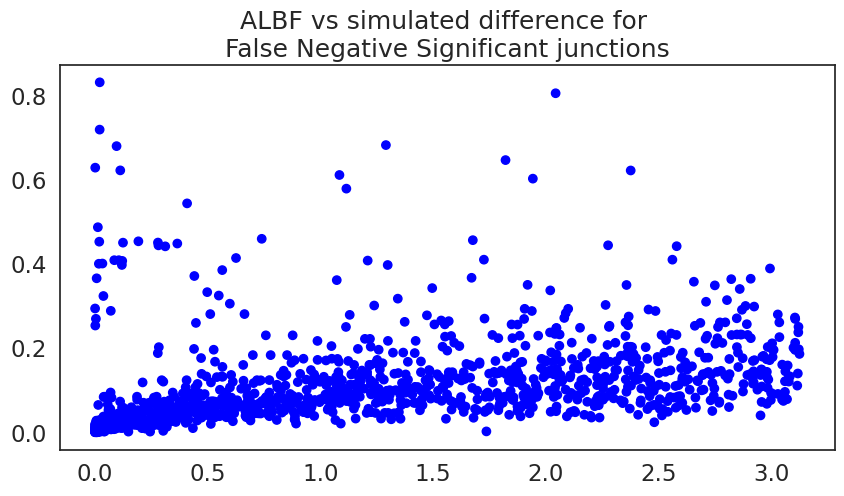

In [47]:
# plot ALBF vs difference for FNS junctions
plt.figure(figsize=(10, 5))
plt.scatter(FNS["ALBF"], FNS["difference"], c=FNS["FDR_thres_0.95"].map({True: "red", False: "blue"}))
plt.title("ALBF vs simulated difference for \nFalse Negative Significant junctions")

<Axes: xlabel='difference', ylabel='Count'>

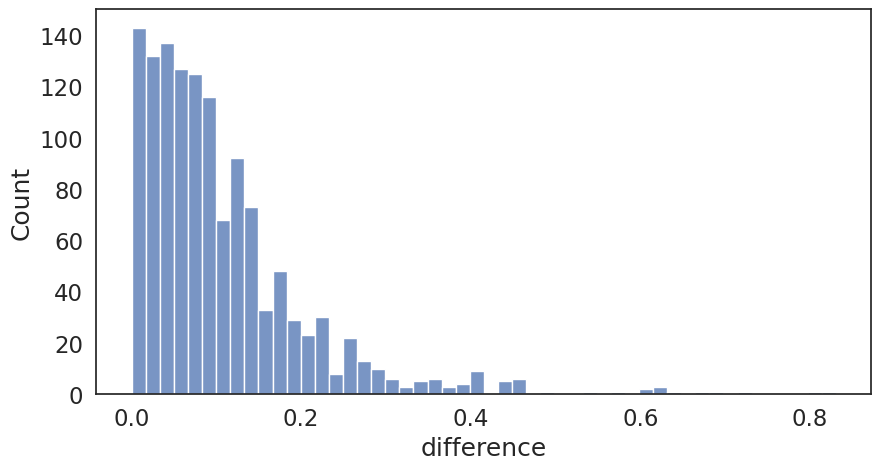

In [48]:
# plot distribution of difference for FNS junctions
plt.figure(figsize=(10, 5))
sns.histplot(FNS["difference"], bins=50)

In [49]:
# find which row in albf_scores is junction_id_index 12181
albf_scores.reset_index(drop=True, inplace=True)

In [55]:
PSI_df[PSI_df["junction_id_index"] == 2245]

,index,0,1,junction_id_index,junction_id,sample_label,Cluster,difference,true_label
2245,1,0.169726,0.97461,2245,chr12_50395040_50425438_-,positive,43882,0.804883,positive


In [57]:
albf_scores[albf_scores["junction_id_index"] == 2245]

,latent_psi_1,latent_psi_2,junction_id_index,ALBF,difference,true_label,Cluster,true_label_binary,delta_est,predicted_label,...,loc_1,posterior_probs,FDR_thres_0.8,FDR_thres_0.9,FDR_thres_0.95,FDR_thres_0.975,FDR_thres_0.99,sigmoid_ALBF,ALBF_standardized,ALBF_standardized_sigmoid
8844,0.003775,0.054064,2245,2.042871,0.804883,positive,43882,1,0.050289,1,...,0.5251,0.865533,True,False,False,False,False,0.885225,-0.336811,0.416584


In [56]:
FNS.sort_values(by="difference")

,latent_psi_1,latent_psi_2,junction_id_index,ALBF,difference,true_label,Cluster,true_label_binary,delta_est,predicted_label,...,loc_1,posterior_probs,FDR_thres_0.8,FDR_thres_0.9,FDR_thres_0.95,FDR_thres_0.975,FDR_thres_0.99,sigmoid_ALBF,ALBF_standardized,ALBF_standardized_sigmoid
1100,1.632392e-01,0.166896,4398,0.001381,0.000196,positive,51854,1,0.003657,0,...,0.027764,0.455254,False,False,False,False,False,0.500345,-0.372527,0.407930
4291,1.661169e-01,0.169734,4400,0.008991,0.000196,positive,51854,1,0.003617,0,...,0.037265,0.457142,False,False,False,False,False,0.502248,-0.372394,0.407963
3483,6.702830e-01,0.665694,4399,0.006187,0.000392,positive,51854,1,0.004589,0,...,0.027495,0.456446,False,False,False,False,False,0.501547,-0.372443,0.407951
322,1.971337e-01,0.198080,2187,0.000362,0.000649,positive,43376,1,0.000946,0,...,0.024285,0.455001,False,False,False,False,False,0.500091,-0.372545,0.407926
5580,2.006614e-01,0.191620,2189,0.016182,0.000649,positive,43376,1,0.009041,0,...,0.022570,0.458927,False,False,False,False,False,0.504045,-0.372269,0.407993
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7670,1.442476e-01,0.063487,8044,0.095994,0.679388,positive,8646,1,0.080761,0,...,7.962603,0.478800,False,False,False,False,False,0.523980,-0.370872,0.408330
8608,2.067963e-01,0.757561,10591,1.290357,0.681874,positive,15490,1,0.550764,1,...,2.583512,0.752038,False,False,False,False,False,0.784208,-0.349977,0.413388
6085,9.524527e-01,0.947289,7510,0.021042,0.718568,positive,5834,1,0.005163,0,...,0.213922,0.460134,False,False,False,False,False,0.505260,-0.372183,0.408014
8844,3.774957e-03,0.054064,2245,2.042871,0.804883,positive,43882,1,0.050289,1,...,0.525100,0.865533,True,False,False,False,False,0.885225,-0.336811,0.416584


The means are: tensor([-5.6715, -2.9886], dtype=torch.float64)
The variances are: tensor([0.3633, 0.5251], dtype=torch.float64)
The combined mean is: -4.537855625152588
The combined variance is: 0.4316648244857788
The means are: [-5.6715274, -2.9885783, -4.537855625152588]
The variances are: [0.36329412, 0.5251004, 0.4316648244857788]
The mean of the sampled PSI values is: 0.003146104759269494
The mean of the sampled PSI values is: 0.04696406477532707
The mean of the sampled PSI values is: 0.012435414029741727


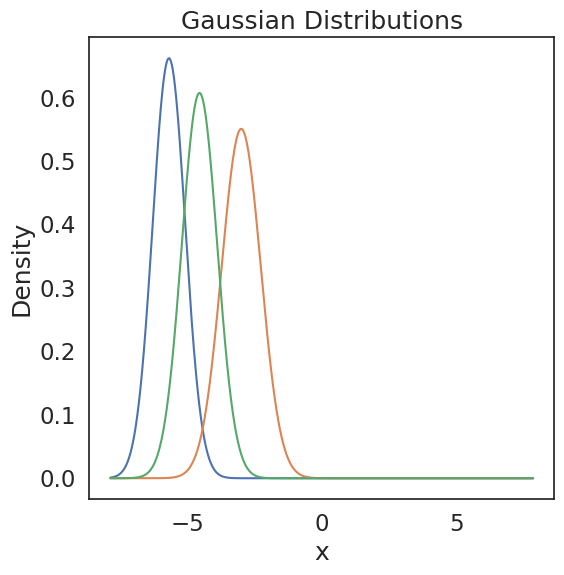

In [58]:
plot_junc_dists(albf_scores, 8844, pis)

In [60]:
# what's our final count of FP, TP, FN, TN at 0.95 threshold
tp = albf_scores[(albf_scores["true_label"] == "positive") & (albf_scores["FDR_thres_0.95"])].shape[0]
fp = albf_scores[(albf_scores["true_label"] == "negative") & (albf_scores["FDR_thres_0.95"])].shape[0]
tn = albf_scores[(albf_scores["true_label"] == "negative") & (~albf_scores["FDR_thres_0.95"])].shape[0]
fn = albf_scores[(albf_scores["true_label"] == "positive") & (~albf_scores["FDR_thres_0.95"])].shape[0]

fdr = fp / (fp + tp)
fnr = fn / (fn + tp)

print(f"At 0.95 threshold on FDR, number of true positives: {tp}, number of false positives: {fp}")
print(f"At 0.95 threshold on FDR, number of true negatives: {tn}, number of false negatives: {fn}")
print(f"At 0.95 threshold on FDR, False Discovery Rate: {fdr:.2f}")
print(f"At 0.95 threshold on FDR, False Negative Rate: {fnr:.2f}")

At 0.95 threshold on FDR, number of true positives: 6657, number of false positives: 67
At 0.95 threshold on FDR, number of true negatives: 7880, number of false negatives: 1290
At 0.95 threshold on FDR, False Discovery Rate: 0.01
At 0.95 threshold on FDR, False Negative Rate: 0.16


In [61]:
# calcualte pearson and spearman correlation between ALBF and simulated difference
pearson_corr = stats.pearsonr(albf_scores["ALBF"], albf_scores["difference"])
spearman_corr = stats.spearmanr(albf_scores["ALBF"], albf_scores["difference"])

print(f"Pearson correlation between ALBF and simulated difference: {pearson_corr}")
print(f"Spearman correlation between ALBF and simulated difference: {spearman_corr}")

Pearson correlation between ALBF and simulated difference: PearsonRResult(statistic=0.5880148010575053, pvalue=0.0)
Spearman correlation between ALBF and simulated difference: SignificanceResult(statistic=0.8909511522447011, pvalue=0.0)
